In [1]:
# =========================================
# 1. IMPORTS
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [72]:
# =========================================
# 2. LOAD DATASET
# =========================================

df = pd.read_csv("data/credit_risk_dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [73]:
# =========================================
# 3. BASIC INFO
# =========================================

print("\nColumn Info:\n")
print(df.info())


Column Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


In [74]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [75]:
cat_columns = df.select_dtypes(include=["object"]).columns

for column in cat_columns:
    print(f"{column}: {df[column].unique()}")

person_home_ownership: ['RENT' 'OWN' 'MORTGAGE' 'OTHER']
loan_intent: ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']
loan_grade: ['D' 'B' 'C' 'A' 'E' 'F' 'G']
cb_person_default_on_file: ['Y' 'N']


In [5]:
print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nTarget Distribution:\n")
print(df["loan_status"].value_counts())
print(df["loan_status"].value_counts(normalize=True))


Missing Values:

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Target Distribution:

loan_status
0    25473
1     7108
Name: count, dtype: int64
loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64


In [6]:
# =========================================
# HANDLE MISSING VALUES
# =========================================

df["person_emp_length"].fillna(df["person_emp_length"].median(), inplace=True)
df["loan_int_rate"].fillna(df["loan_int_rate"].median(), inplace=True)

# Check if any missing values remain
missing_after = df.isnull().sum()
print(missing_after[missing_after > 0])  # only columns still having missing

Series([], dtype: int64)


/var/folders/x2/p857nctj7hndgfwnttbcz4jh0000gn/T/ipykernel_13555/3993450684.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["person_emp_length"].fillna(df["person_emp_length"].median(), inplace=True)
/var/folders/x2/p857nctj7hndgfwnttbcz4jh0000gn/T/ipykernel_13555/3993450684.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on wh

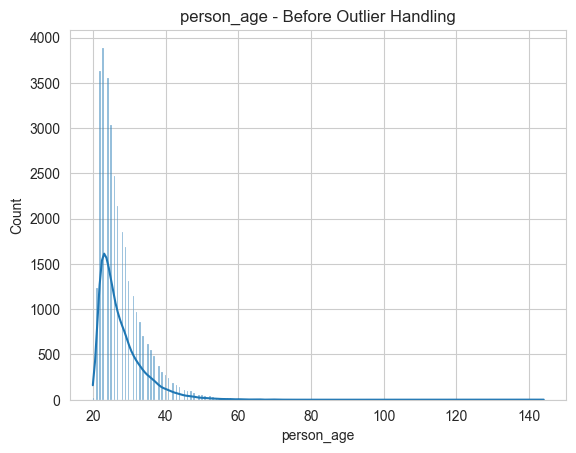

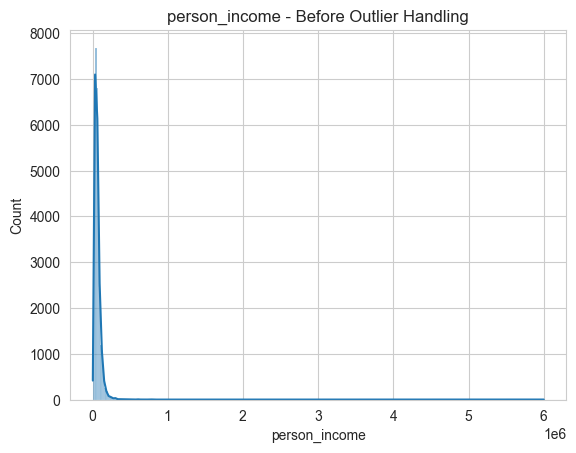

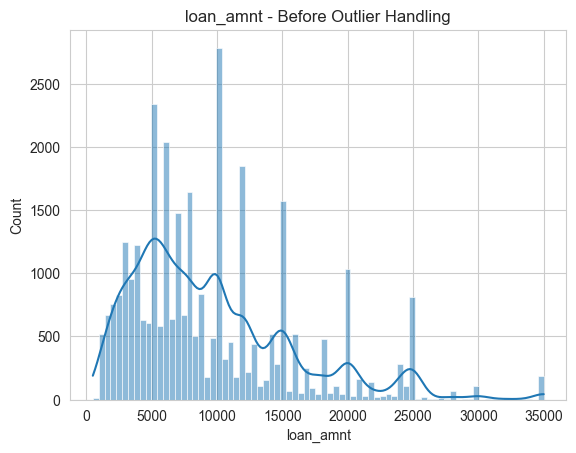

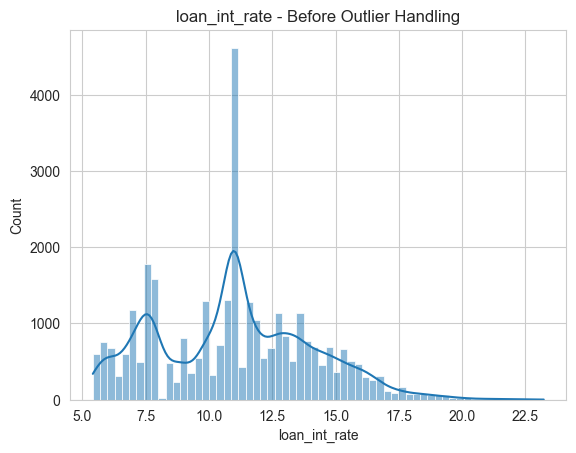

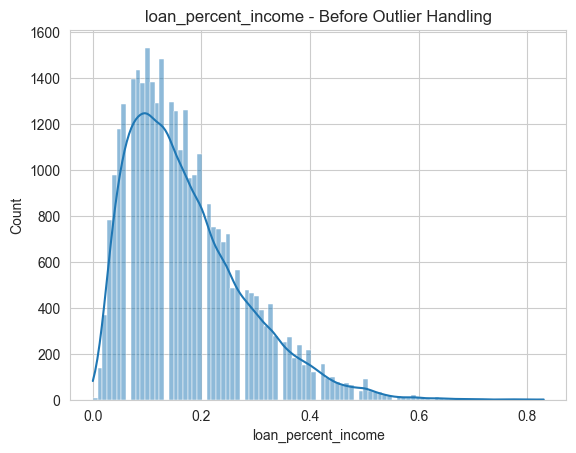

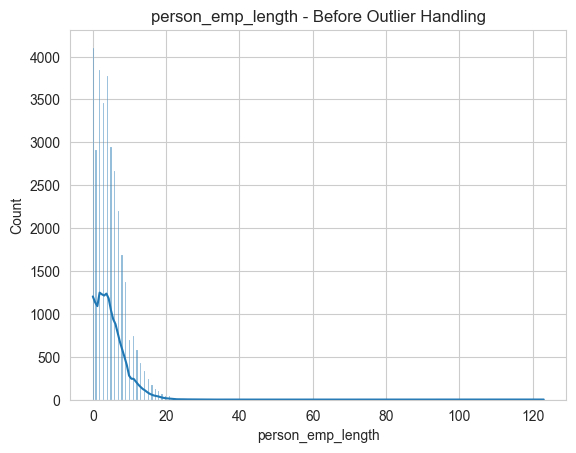

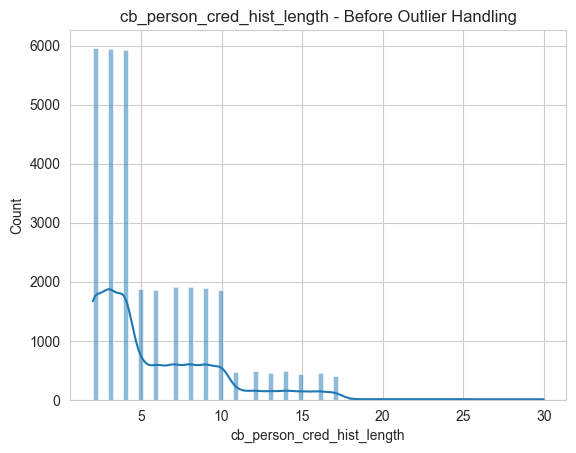

In [7]:
# =========================================
# DISTRIBUTIONS BEFORE OUTLIERS
# =========================================

cols_to_plot = [
    "person_age",
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "person_emp_length",
    "cb_person_cred_hist_length"
]

for col in cols_to_plot:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} - Before Outlier Handling")
    plt.show()

In [ ]:
# =========================================
# OUTLIER HANDLING
# =========================================

def cap_outliers(df, cols, lower_quantile=0.01, upper_quantile=0.99):
    df = df.copy()
    bounds = {}

    for col in cols:
        lower = df[col].quantile(lower_quantile)
        upper = df[col].quantile(upper_quantile)
        
        df[col] = df[col].clip(lower, upper)

        bounds[col] = (lower, upper)
        
    return df, bounds

# QUANTILE-BASED CAPPING
outlier_cols = [
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income"
]

df_clean, quantile_bounds = cap_outliers(df, outlier_cols)

# DOMAIN-BASED CLIPPING
df_clean["person_age"] = df_clean["person_age"].clip(18, 80)
df_clean["person_emp_length"] = df_clean["person_emp_length"].clip(0, 40)
df_clean["cb_person_cred_hist_length"] = df_clean["cb_person_cred_hist_length"].clip(0, 30)

# Ensure logical consistency
df_clean["person_emp_length"] = np.minimum(
    df_clean["person_emp_length"],
    df_clean["person_age"] - 18
)

print("Outlier handling done.")

Outlier handling done.


/var/folders/x2/p857nctj7hndgfwnttbcz4jh0000gn/T/ipykernel_13555/838734931.py:13: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].clip(lower, upper)


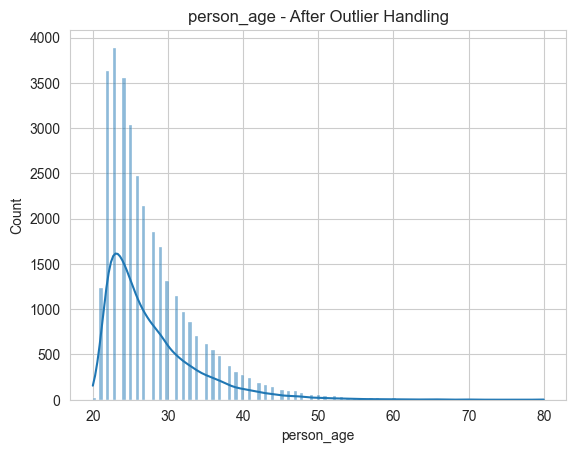

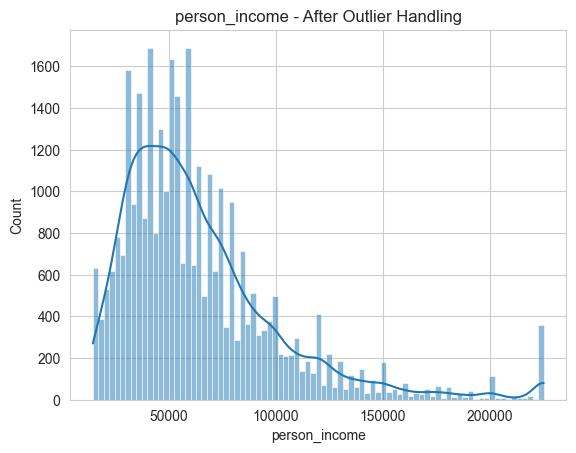

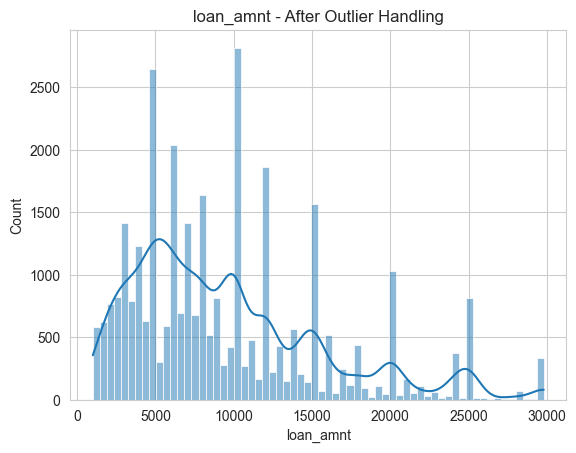

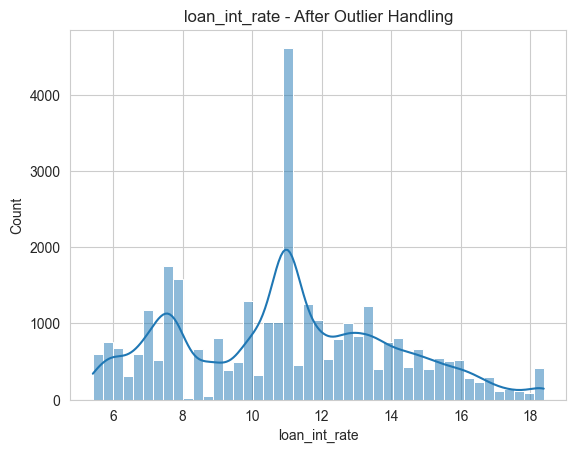

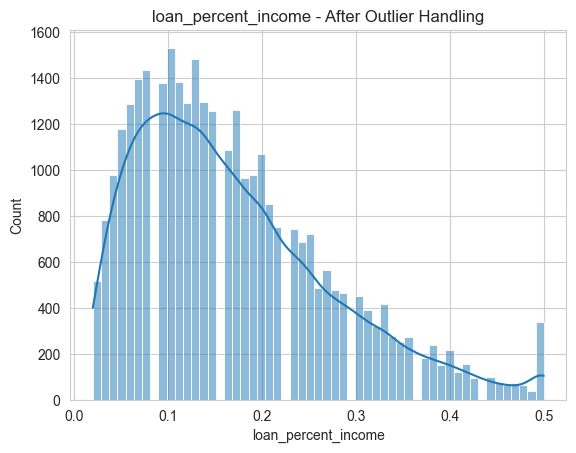

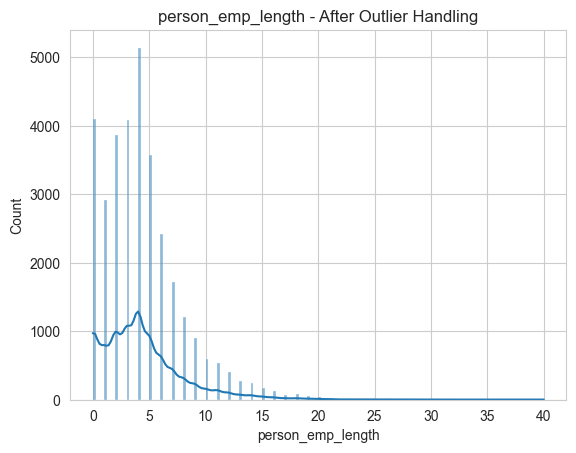

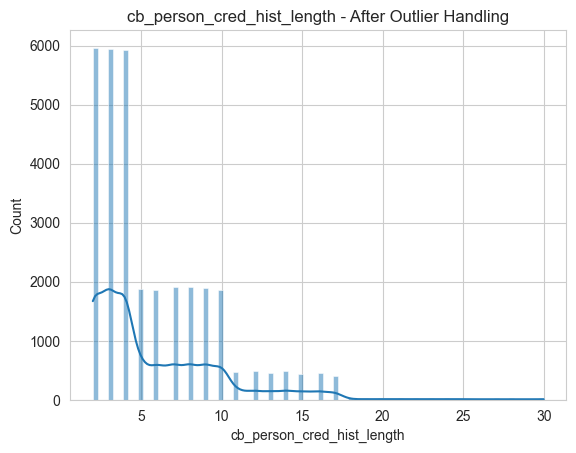

In [9]:
# =========================================
# DISTRIBUTIONS AFTER OUTLIERS
# =========================================

for col in cols_to_plot:
    plt.figure()
    sns.histplot(df_clean[col], kde=True)
    plt.title(f"{col} - After Outlier Handling")
    plt.show()

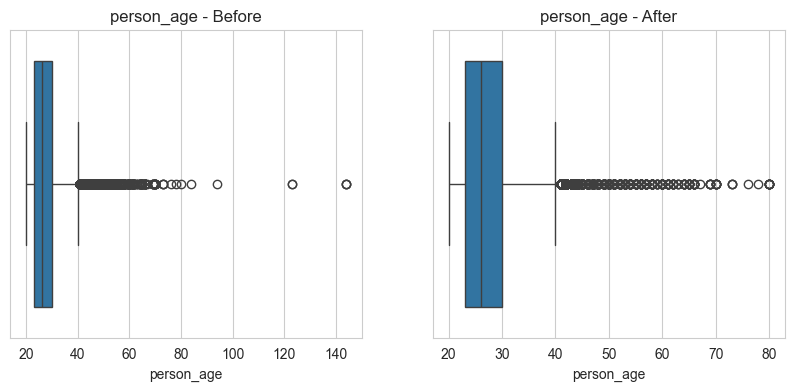

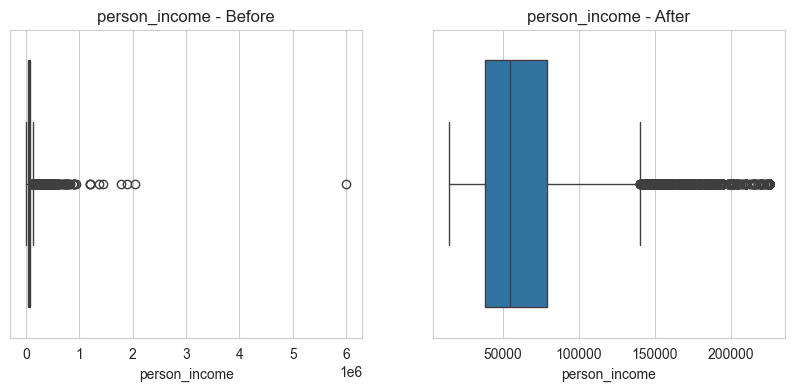

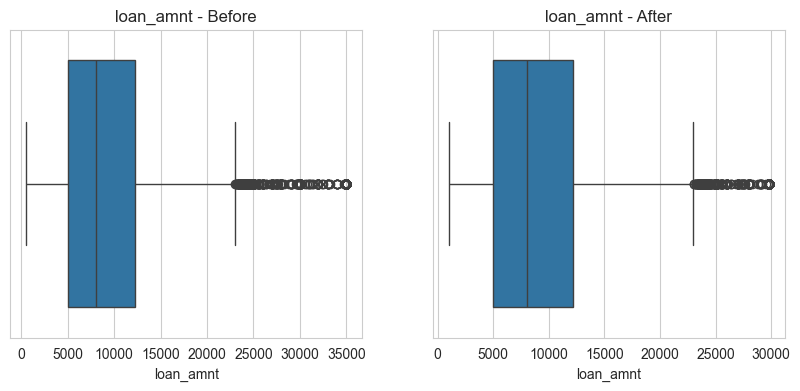

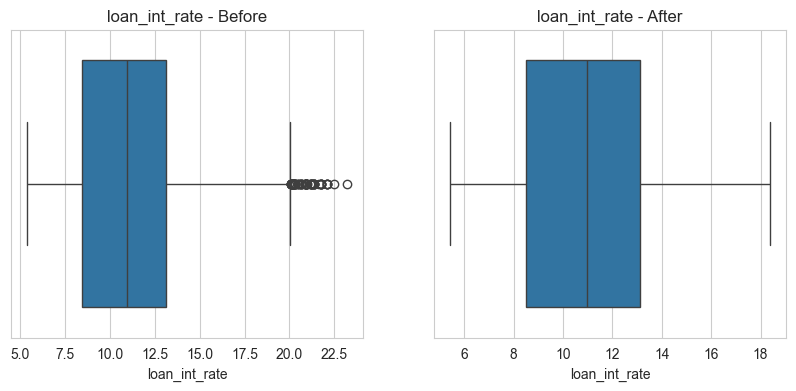

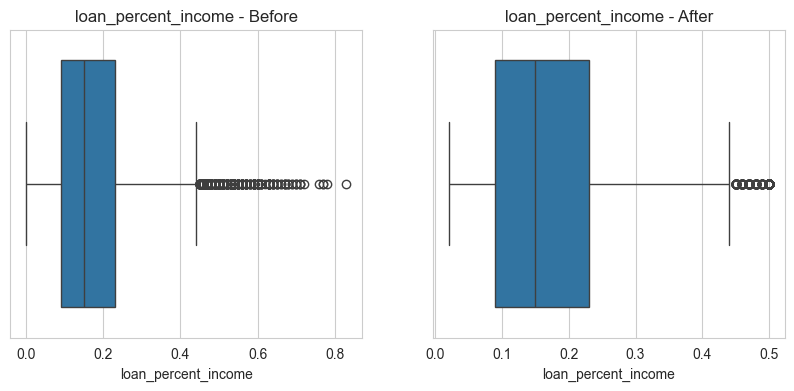

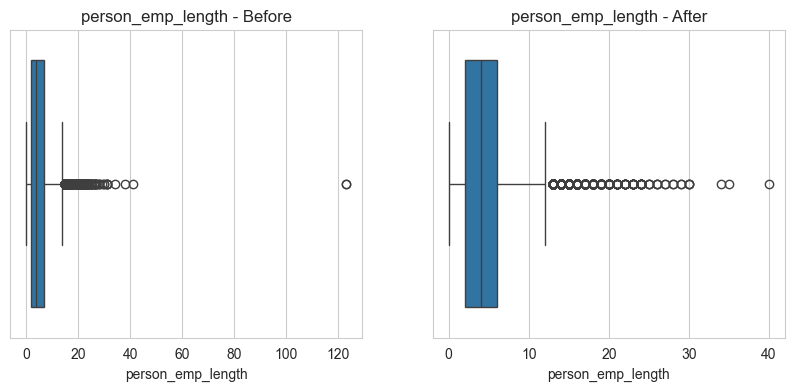

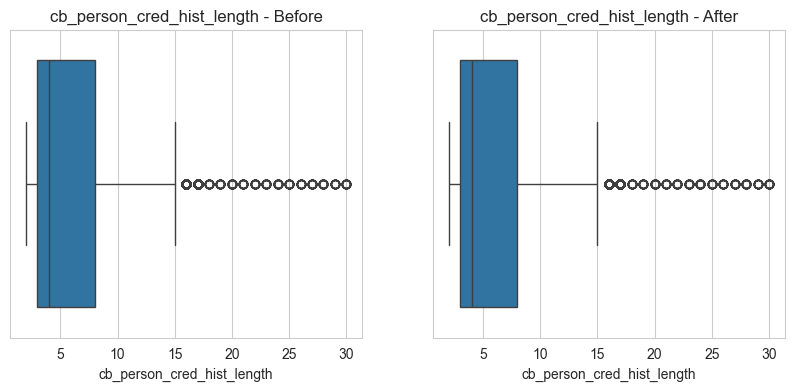

In [10]:
# ===================================================
# DISTRIBUTIONS BEFORE & AFTER OUTLIERS COMPARISON
# ===================================================

for col in cols_to_plot:
    plt.figure(figsize=(10,4))
    
    plt.subplot(1,2,1)
    sns.boxplot(x=df[col])
    plt.title(f"{col} - Before")
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df_clean[col])
    plt.title(f"{col} - After")
    
    plt.show()

In [11]:
df_clean.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.000000,32581.00000,32581.000000
mean,27.725515,64368.147970,4.290292,9556.484608,10.999018,0.218164,0.16974,5.804211
std,6.233069,37761.494419,3.565878,6202.355384,3.052916,0.413006,0.10482,4.055001
min,20.000000,14400.000000,0.000000,1000.000000,5.420000,0.000000,0.02000,2.000000
25%,23.000000,38500.000000,2.000000,5000.000000,8.490000,0.000000,0.09000,3.000000
50%,26.000000,55000.000000,4.000000,8000.000000,10.990000,0.000000,0.15000,4.000000
75%,30.000000,79200.000000,6.000000,12200.000000,13.110000,0.000000,0.23000,8.000000
max,80.000000,225200.000000,40.000000,29800.000000,18.390000,1.000000,0.50000,30.000000


In [12]:
df = df_clean

In [13]:
# =========================================
# 4. FEATURES & TARGET
# =========================================

X = df.drop("loan_status", axis=1)
y = df["loan_status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32581, 11)
y shape: (32581,)


In [14]:
# =========================================
# 5. TRAIN / VAL / TEST SPLIT
# =========================================

from sklearn.model_selection import train_test_split

# First split: train vs temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Split temp into validation + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTrain distribution:\n", y_train.value_counts(normalize=True))
print("\nValidation distribution:\n", y_val.value_counts(normalize=True))
print("\nTest distribution:\n", y_test.value_counts(normalize=True))

Train: (22806, 11)
Validation: (4887, 11)
Test: (4888, 11)

Train distribution:
 loan_status
0    0.781856
1    0.218144
Name: proportion, dtype: float64

Validation distribution:
 loan_status
0    0.78187
1    0.21813
Name: proportion, dtype: float64

Test distribution:
 loan_status
0    0.78171
1    0.21829
Name: proportion, dtype: float64


In [15]:
# =========================================
# 6. PREPROCESSING PIPELINE
# =========================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

numerical_features = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

# Numeric pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


In [16]:
# ==============================
# EXPERIMENT 1: MODEL COMPARISON
# ==============================

In [17]:
# =========================================
# 7. MODEL DEFINITIONS
# =========================================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier

def get_models(preprocessor):
    models = {
        "Logistic Regression": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", LogisticRegression(max_iter=1000, random_state=42))
        ]),

        "SVM": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", SVC(probability=True, random_state=42))
        ]),
        
        "Decision Tree": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", DecisionTreeClassifier(random_state=42))
        ]),
        
        "Random Forest": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
        ]),
        
        "XGBoost": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42
            ))
        ]),
        
        "LightGBM": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", LGBMClassifier(
                n_estimators=200,
                learning_rate=0.1,
                random_state=42
            ))
        ]),
        
        "Neural Network": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", MLPClassifier(
                hidden_layer_sizes=(64, 32),
                max_iter=300,
                random_state=42
            ))
        ])
    }
    
    return models

In [18]:
# =========================================
# CROSS-VALIDATION (DETAILED)
# =========================================

from sklearn.model_selection import cross_validate, StratifiedKFold

def cross_validate_detailed(model, X, y, cv=5):
    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }

    cv_strategy = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    scores = cross_validate(
        model,
        X,
        y,
        cv=cv_strategy,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    return scores

In [19]:
# =========================================
# 9. RUN CROSS-VALIDATION
# =========================================
models = get_models(preprocessor)

all_fold_results = {}

for name, model in models.items():
    print(f"\nRunning CV for {name}...")
    
    scores = cross_validate_detailed(model, X_train, y_train)
    
    fold_df = pd.DataFrame({
        "Fold": range(1, 6),
        "Accuracy": scores["test_accuracy"],
        "Precision": scores["test_precision"],
        "Recall": scores["test_recall"],
        "F1": scores["test_f1"],
        "ROC-AUC": scores["test_roc_auc"]
    })
    
    all_fold_results[name] = fold_df


Running CV for Logistic Regression...

Running CV for SVM...

Running CV for Decision Tree...

Running CV for Random Forest...

Running CV for XGBoost...

Running CV for LightGBM...
[LightGBM] [Info] Number of positive: 3980, number of negative: 14265
[LightGBM] [Info] Number of positive: 3980, number of negative: 14265
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 912
[LightGBM] [Info] Number of data points in the train set: 18245, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218142 -> initscore=-1.276527
[LightGBM] [Info] Start training from score -1.276527
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000903 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 

/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fit


Running CV for Neural Network...


/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-pa

In [20]:
# =========================================
# COMBINED FOLD RESULTS (ALL MODELS)
# =========================================

combined_folds_df = []

for model_name, df_fold in all_fold_results.items():
    temp_df = df_fold.copy()
    temp_df["Model"] = model_name
    combined_folds_df.append(temp_df)

combined_folds_df = pd.concat(combined_folds_df, ignore_index=True)

# Reorder columns nicely
combined_folds_df = combined_folds_df[
    ["Model", "Fold", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
]

combined_folds_df

,Model,Fold,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,1,0.863875,0.771014,0.534673,0.631454,0.862954
1,Logistic Regression,2,0.869327,0.782178,0.555779,0.649824,0.874955
2,Logistic Regression,3,0.871739,0.771164,0.585930,0.665905,0.870071
3,Logistic Regression,4,0.859899,0.741848,0.548744,0.630849,0.865472
4,Logistic Regression,5,0.862092,0.745968,0.557789,0.638298,0.865986
5,SVM,1,0.911662,0.934018,0.640201,0.759690,0.893443
6,SVM,2,0.915589,0.933239,0.660302,0.773396,0.897205
7,SVM,3,0.914712,0.939130,0.651256,0.769139,0.904013
8,SVM,4,0.907476,0.933434,0.620101,0.745169,0.897690
9,SVM,5,0.909450,0.918103,0.642211,0.755766,0.899486


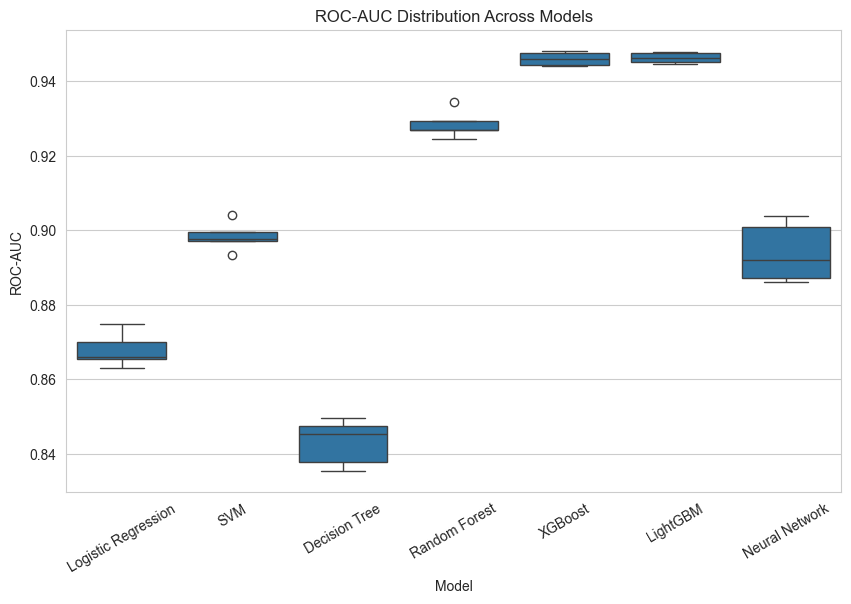

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=combined_folds_df, x="Model", y="ROC-AUC")
plt.xticks(rotation=30)
plt.title("ROC-AUC Distribution Across Models")
plt.show()

In [22]:
summary_stats = []

for name, df_fold in all_fold_results.items():
    summary_stats.append({
        "Model": name,
        "Mean ROC-AUC": df_fold["ROC-AUC"].mean(),
        "Std ROC-AUC": df_fold["ROC-AUC"].std(),
        "Mean Recall": df_fold["Recall"].mean(),
        "Std Recall": df_fold["Recall"].std()
    })

summary_df = pd.DataFrame(summary_stats)
summary_df = summary_df.sort_values(by="Mean ROC-AUC", ascending=False).reset_index(drop=True)
summary_df["CV% (AUC)"] = (summary_df["Std ROC-AUC"] / summary_df["Mean ROC-AUC"]) * 100

summary_df

,Model,Mean ROC-AUC,Std ROC-AUC,Mean Recall,Std Recall,CV% (AUC)
0,LightGBM,0.946336,0.001457,0.731658,0.006195,0.153991
1,XGBoost,0.946076,0.001844,0.727437,0.010740,0.194958
2,Random Forest,0.928458,0.003818,0.713970,0.006380,0.411194
3,SVM,0.898367,0.003846,0.642814,0.015001,0.428165
4,Neural Network,0.894011,0.007952,0.714171,0.009837,0.889449
5,Logistic Regression,0.867888,0.004704,0.556583,0.018740,0.541984
6,Decision Tree,0.843124,0.006233,0.763417,0.011472,0.739233


In [23]:
# Example Standard Deviation Calculation for XGBoost

print("STD DEV (XGBoost):")
print("Accuracy:", np.std(scores["test_accuracy"]))
print("Precision:", np.std(scores["test_precision"]))
print("Recall:", np.std(scores["test_recall"]))
print("F1:", np.std(scores["test_f1"]))
print("ROC-AUC:", np.std(scores["test_roc_auc"]))

STD DEV (XGBoost):
Accuracy: 0.003086913374957535
Precision: 0.01828607935235617
Recall: 0.008798419549040933
F1: 0.004833265124122871
ROC-AUC: 0.007112277422600614


In [24]:
# =========================================
# 10. FINAL TEST EVALUATION
# =========================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

test_results = []

for name, model in models.items():
    print(f"Training {name} on full training data...")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

test_results_df = pd.DataFrame(test_results)
test_results_df = test_results_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

test_results_df

Training Logistic Regression on full training data...
Training SVM on full training data...
Training Decision Tree on full training data...
Training Random Forest on full training data...
Training XGBoost on full training data...
Training LightGBM on full training data...
[LightGBM] [Info] Number of positive: 4975, number of negative: 17831
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000468 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 913
[LightGBM] [Info] Number of data points in the train set: 22806, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218144 -> initscore=-1.276513
[LightGBM] [Info] Start training from score -1.276513


/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training Neural Network on full training data...


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,LightGBM,0.937807,0.968098,0.739456,0.838470,0.952536
1,XGBoost,0.935966,0.956416,0.740394,0.834654,0.952449
2,Random Forest,0.935147,0.965261,0.729147,0.830753,0.930292
3,Neural Network,0.917962,0.891765,0.710403,0.790819,0.905634
4,SVM,0.913871,0.925000,0.658857,0.769568,0.901870
5,Logistic Regression,0.868658,0.767970,0.570759,0.654839,0.870926
6,Decision Tree,0.890548,0.730503,0.790066,0.759118,0.854337


/var/folders/x2/p857nctj7hndgfwnttbcz4jh0000gn/T/ipykernel_13555/1377438077.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=test_results_df, x="Model", y="ROC-AUC", palette="viridis")


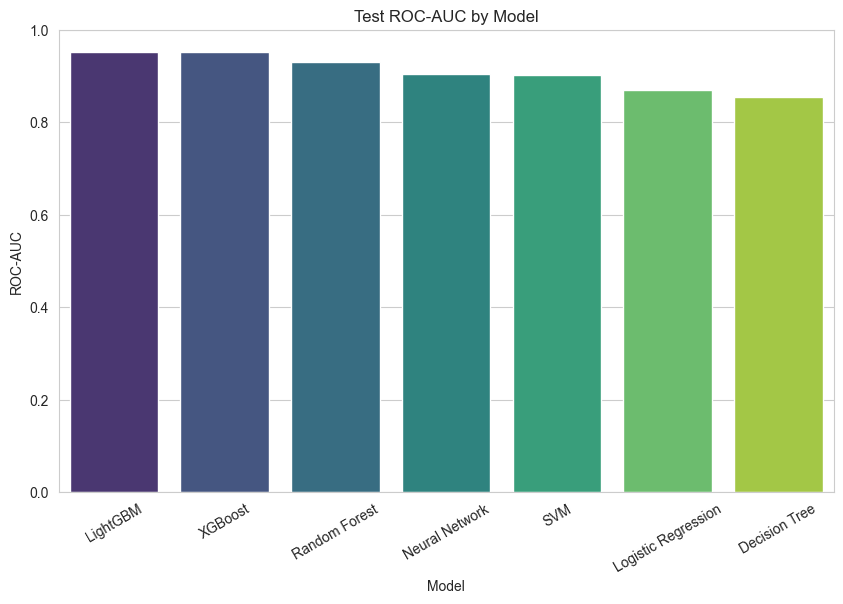

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=test_results_df, x="Model", y="ROC-AUC", palette="viridis")
plt.title("Test ROC-AUC by Model")
plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

In [26]:
# ==========================================
# EXPERIMENT 2A: CLASS IMBALANCE STRESS TEST
# ==========================================

In [27]:
# =========================================
# CREATE IMBALANCED DATASET
# =========================================

def create_imbalanced_data(X, y, target_ratio=0.1, random_state=42):
    df_temp = X.copy()
    df_temp["target"] = y.values
    
    # Separate classes
    df_majority = df_temp[df_temp["target"] == 0]
    df_minority = df_temp[df_temp["target"] == 1]
    
    # Desired minority count
    desired_minority = int(len(df_majority) * target_ratio / (1 - target_ratio))
    
    # Downsample minority
    df_minority_downsampled = df_minority.sample(
        n=desired_minority,
        random_state=random_state
    )
    
    df_balanced = pd.concat([df_majority, df_minority_downsampled])
    
    # Shuffle
    df_balanced = df_balanced.sample(frac=1, random_state=random_state)
    
    X_new = df_balanced.drop("target", axis=1)
    y_new = df_balanced["target"]
    
    return X_new, y_new

In [28]:
# 90/10 dataset
X_train_90, y_train_90 = create_imbalanced_data(X_train, y_train, target_ratio=0.10)

# 95/5 dataset
X_train_95, y_train_95 = create_imbalanced_data(X_train, y_train, target_ratio=0.05)

print("Original:", y_train.value_counts(normalize=True))
print("90/10:", y_train_90.value_counts(normalize=True))
print("95/5:", y_train_95.value_counts(normalize=True))

Original: loan_status
0    0.781856
1    0.218144
Name: proportion, dtype: float64
90/10: target
0    0.90001
1    0.09999
Name: proportion, dtype: float64
95/5: target
0    0.950024
1    0.049976
Name: proportion, dtype: float64


In [29]:
def evaluate_models(models, X_train, y_train, X_test, y_test):
    results = []
    
    for name, model in models.items():
        print(f"Training {name}...")
        
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
        
        results.append({
            "Model": name,
            "Recall": recall_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
            "ROC-AUC": roc_auc_score(y_test, y_prob)
        })
    
    return pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)

In [30]:
# Original
results_original = evaluate_models(models, X_train, y_train, X_test, y_test)

# 90/10
results_90 = evaluate_models(models, X_train_90, y_train_90, X_test, y_test)

# 95/5
results_95 = evaluate_models(models, X_train_95, y_train_95, X_test, y_test)

Training Logistic Regression...
Training SVM...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Number of positive: 4975, number of negative: 17831
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000459 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 913
[LightGBM] [Info] Number of data points in the train set: 22806, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218144 -> initscore=-1.276513
[LightGBM] [Info] Start training from score -1.276513


/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training Neural Network...
Training Logistic Regression...
Training SVM...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Number of positive: 1981, number of negative: 17831
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 904
[LightGBM] [Info] Number of data points in the train set: 19812, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.099990 -> initscore=-2.197337
[LightGBM] [Info] Start training from score -2.197337


/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training Neural Network...


/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Training Logistic Regression...
Training SVM...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Number of positive: 938, number of negative: 17831
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000435 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 902
[LightGBM] [Info] Number of data points in the train set: 18769, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.049976 -> initscore=-2.944944
[LightGBM] [Info] Start training from score -2.944944


/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training Neural Network...


In [31]:
print("=== ORIGINAL ===")
display(results_original)

print("=== 90/10 ===")
display(results_90)

print("=== 95/5 ===")
display(results_95)

=== ORIGINAL ===


,Model,Recall,Precision,F1,ROC-AUC
5,LightGBM,0.739456,0.968098,0.838470,0.952536
4,XGBoost,0.740394,0.956416,0.834654,0.952449
3,Random Forest,0.729147,0.965261,0.830753,0.930292
6,Neural Network,0.710403,0.891765,0.790819,0.905634
1,SVM,0.658857,0.925000,0.769568,0.901870
0,Logistic Regression,0.570759,0.767970,0.654839,0.870926
2,Decision Tree,0.790066,0.730503,0.759118,0.854337


=== 90/10 ===


,Model,Recall,Precision,F1,ROC-AUC
4,XGBoost,0.711340,0.988281,0.827248,0.941342
5,LightGBM,0.710403,0.986979,0.826158,0.940390
3,Random Forest,0.698219,0.985450,0.817334,0.920304
1,SVM,0.517338,0.976991,0.676471,0.887830
6,Neural Network,0.647610,0.917663,0.759341,0.878466
0,Logistic Regression,0.344892,0.869976,0.493960,0.869270
2,Decision Tree,0.736645,0.823899,0.777833,0.846339


=== 95/5 ===


,Model,Recall,Precision,F1,ROC-AUC
4,XGBoost,0.669166,0.993046,0.799552,0.931484
5,LightGBM,0.675726,0.993113,0.804239,0.927908
3,Random Forest,0.658857,0.994342,0.792559,0.915011
1,SVM,0.390815,0.985816,0.559732,0.871447
0,Logistic Regression,0.211809,0.933884,0.345302,0.866462
2,Decision Tree,0.721649,0.896391,0.799585,0.849179
6,Neural Network,0.590440,0.951662,0.728745,0.847281


In [32]:
# =============================
# EXPERIMENT 2B: BALANCE EFFECT
# =============================

In [33]:
def create_balanced_data(X, y, ratio=0.5, random_state=42):
    df_temp = X.copy()
    df_temp["target"] = y.values

    df_majority = df_temp[df_temp["target"] == 0]
    df_minority = df_temp[df_temp["target"] == 1]

    # Step 1: sample minority safely
    desired_minority = int(len(df_majority) * ratio / (1 - ratio))
    minority_n = min(desired_minority, len(df_minority))

    df_minority_sampled = df_minority.sample(
        n=minority_n,
        random_state=random_state
    )

    # Step 2: compute majority count properly
    majority_n = int(minority_n * (1 - ratio) / ratio)

    df_majority_sampled = df_majority.sample(
        n=majority_n,
        random_state=random_state
    )

    # Combine
    df_new = pd.concat([df_majority_sampled, df_minority_sampled])
    df_new = df_new.sample(frac=1, random_state=random_state)

    X_new = df_new.drop("target", axis=1)
    y_new = df_new["target"]

    return X_new, y_new

In [34]:
# 60/40
X_train_60, y_train_60 = create_balanced_data(X_train, y_train, ratio=0.4)

# 50/50
X_train_50, y_train_50 = create_balanced_data(X_train, y_train, ratio=0.5)

print("60/40:", y_train_60.value_counts(normalize=True))
print("50/50:", y_train_50.value_counts(normalize=True))

60/40: target
0    0.599984
1    0.400016
Name: proportion, dtype: float64
50/50: target
0    0.5
1    0.5
Name: proportion, dtype: float64


In [35]:
results_60 = evaluate_models(models, X_train_60, y_train_60, X_test, y_test)
results_50 = evaluate_models(models, X_train_50, y_train_50, X_test, y_test)

Training Logistic Regression...
Training SVM...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Number of positive: 4975, number of negative: 7462
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000404 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 908
[LightGBM] [Info] Number of data points in the train set: 12437, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.400016 -> initscore=-0.405398
[LightGBM] [Info] Start training from score -0.405398


/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training Neural Network...


/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Training Logistic Regression...
Training SVM...
Training Decision Tree...
Training Random Forest...
Training XGBoost...
Training LightGBM...
[LightGBM] [Info] Number of positive: 4975, number of negative: 4975
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000371 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 913
[LightGBM] [Info] Number of data points in the train set: 9950, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training Neural Network...


/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [36]:
print("=== ORIGINAL ===")
display(results_original)

print("=== 60/40 ===")
display(results_60)

print("=== 50/50 ===")
display(results_50)

=== ORIGINAL ===


,Model,Recall,Precision,F1,ROC-AUC
5,LightGBM,0.739456,0.968098,0.838470,0.952536
4,XGBoost,0.740394,0.956416,0.834654,0.952449
3,Random Forest,0.729147,0.965261,0.830753,0.930292
6,Neural Network,0.710403,0.891765,0.790819,0.905634
1,SVM,0.658857,0.925000,0.769568,0.901870
0,Logistic Regression,0.570759,0.767970,0.654839,0.870926
2,Decision Tree,0.790066,0.730503,0.759118,0.854337


=== 60/40 ===


,Model,Recall,Precision,F1,ROC-AUC
5,LightGBM,0.788191,0.857288,0.821289,0.946818
4,XGBoost,0.783505,0.852192,0.816406,0.945980
3,Random Forest,0.761012,0.833676,0.795688,0.927694
1,SVM,0.731022,0.766208,0.748201,0.905969
6,Neural Network,0.773196,0.678454,0.722733,0.905163
0,Logistic Regression,0.725398,0.617717,0.667241,0.872143
2,Decision Tree,0.806935,0.604635,0.691289,0.829796


=== 50/50 ===


,Model,Recall,Precision,F1,ROC-AUC
5,LightGBM,0.818182,0.741716,0.778075,0.947501
4,XGBoost,0.816307,0.745719,0.779418,0.943936
3,Random Forest,0.797563,0.731100,0.762887,0.927370
6,Neural Network,0.807873,0.575434,0.672125,0.906387
1,SVM,0.776007,0.655582,0.710730,0.905215
0,Logistic Regression,0.787254,0.547231,0.645657,0.872634
2,Decision Tree,0.835052,0.541641,0.657080,0.818861


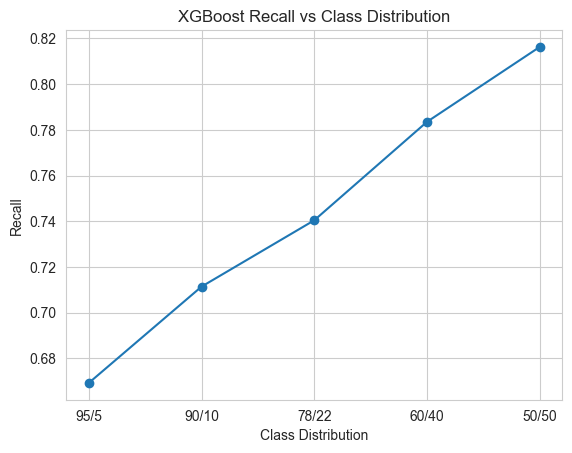

In [37]:
import matplotlib.pyplot as plt

# Example for XGBoost
recalls = [
    results_95.loc[results_95["Model"]=="XGBoost","Recall"].values[0],
    results_90.loc[results_90["Model"]=="XGBoost","Recall"].values[0],
    results_original.loc[results_original["Model"]=="XGBoost","Recall"].values[0],
    results_60.loc[results_60["Model"]=="XGBoost","Recall"].values[0],
    results_50.loc[results_50["Model"]=="XGBoost","Recall"].values[0]
]

labels = ["95/5", "90/10", "78/22", "60/40", "50/50"]

plt.plot(labels, recalls, marker='o')
plt.title("XGBoost Recall vs Class Distribution")
plt.xlabel("Class Distribution")
plt.ylabel("Recall")
plt.show()

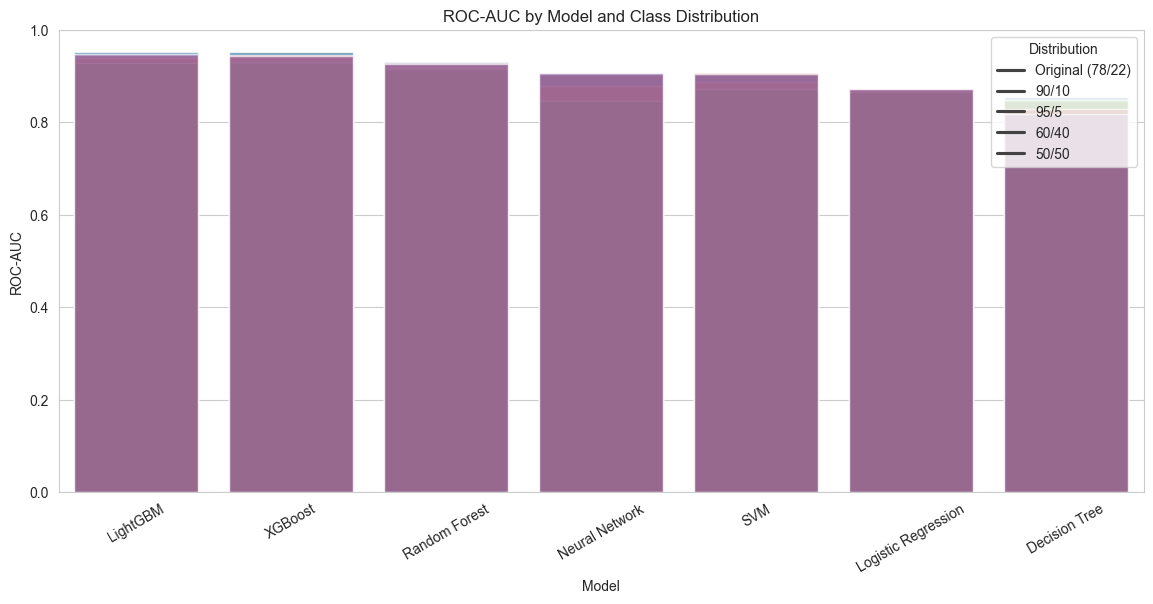

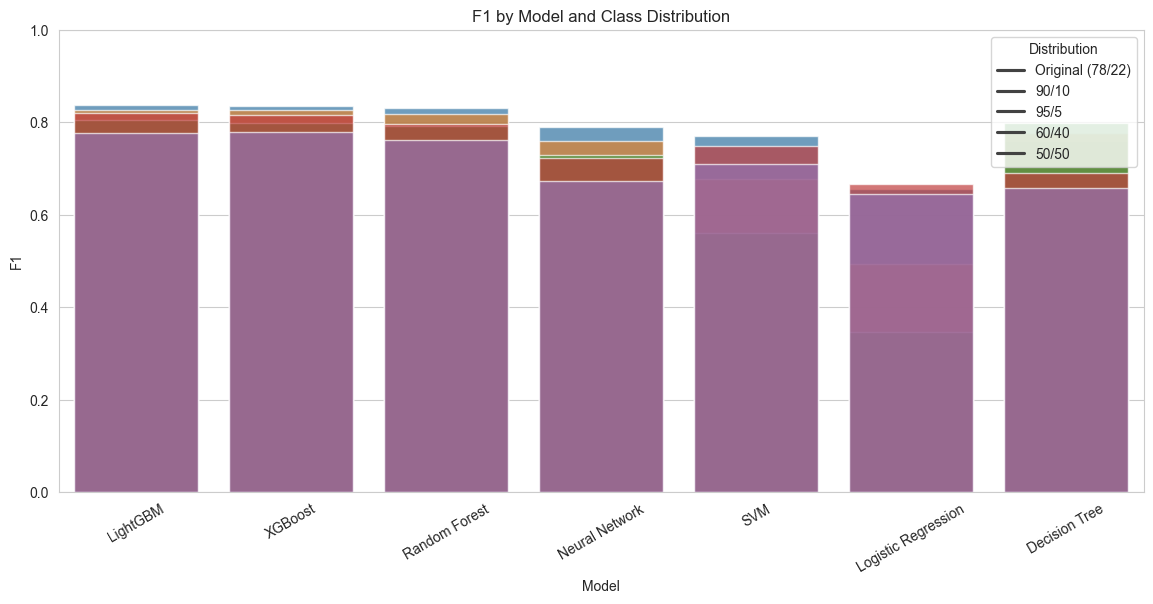

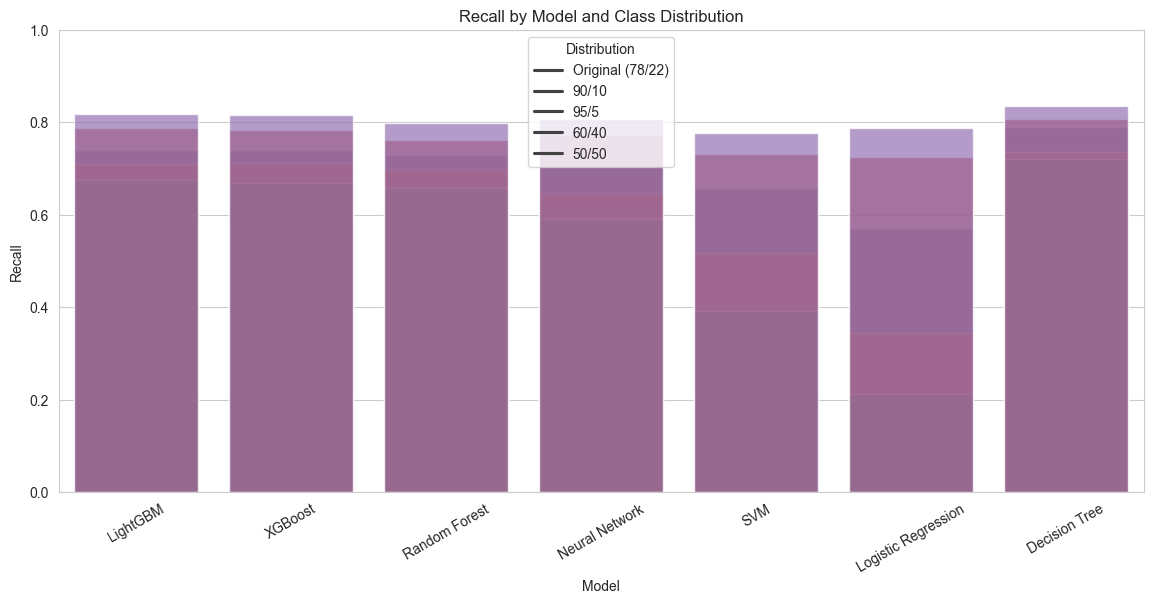

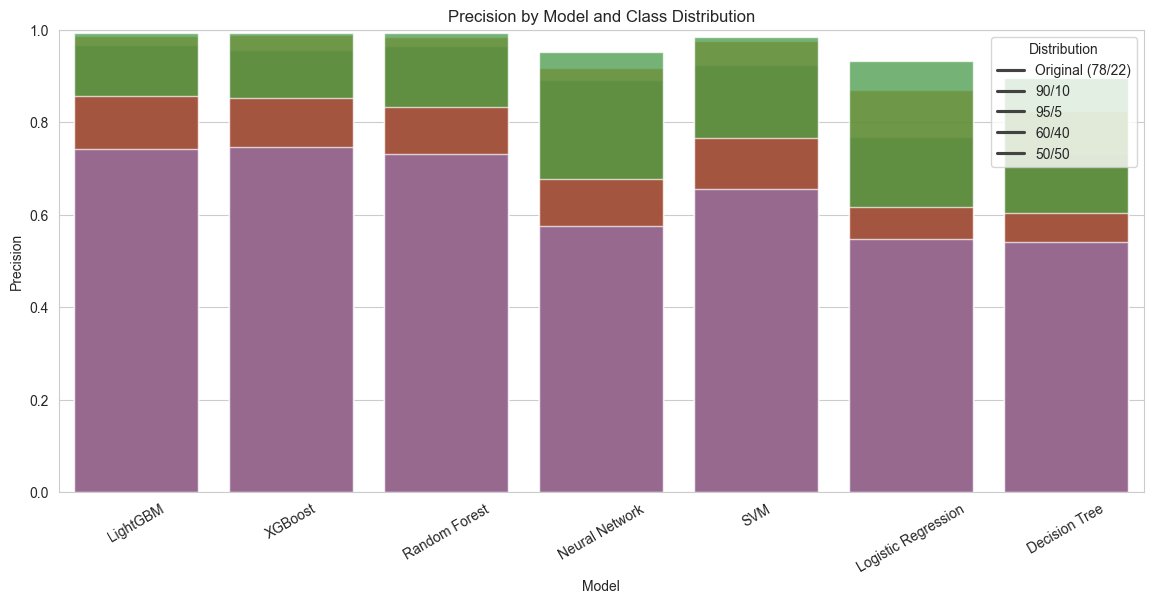

In [38]:
# Barplots: Model Performance under Different Class Distributions
import matplotlib.pyplot as plt
import seaborn as sns

results_dict = {
    "Original (78/22)": results_original,
    "90/10": results_90,
    "95/5": results_95,
    "60/40": results_60,
    "50/50": results_50
}

metrics = ["ROC-AUC", "F1", "Recall", "Precision"]

for metric in metrics:
    plt.figure(figsize=(14, 6))
    for label, df in results_dict.items():
        # Sort models for consistent coloring/order
        plot_df = df.set_index("Model").loc[results_original["Model"]].reset_index()
        sns.barplot(x="Model", y=metric, data=plot_df, label=label, alpha=0.7)
    plt.title(f"{metric} by Model and Class Distribution")
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.xticks(rotation=30)
    plt.legend(results_dict.keys(), title="Distribution")
    plt.ylim(0, 1)
    plt.show()

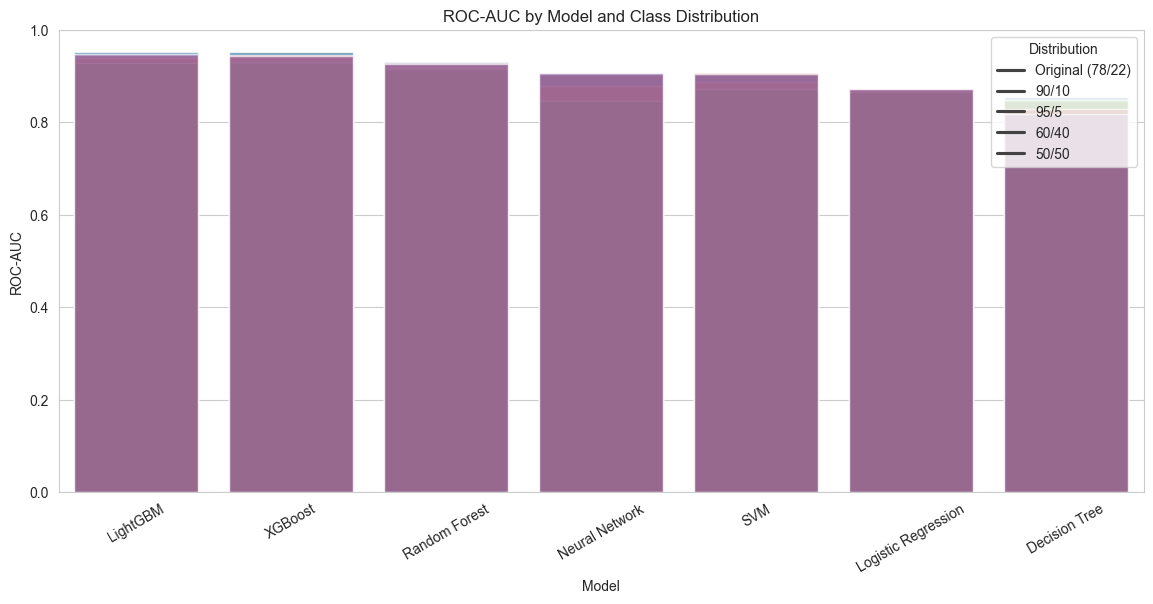

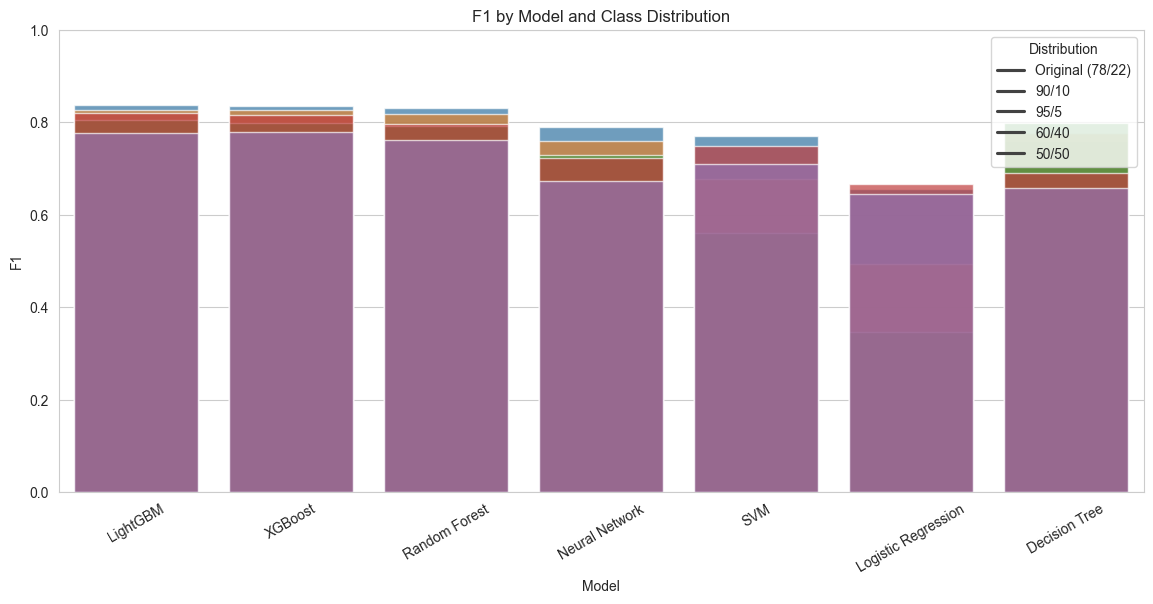

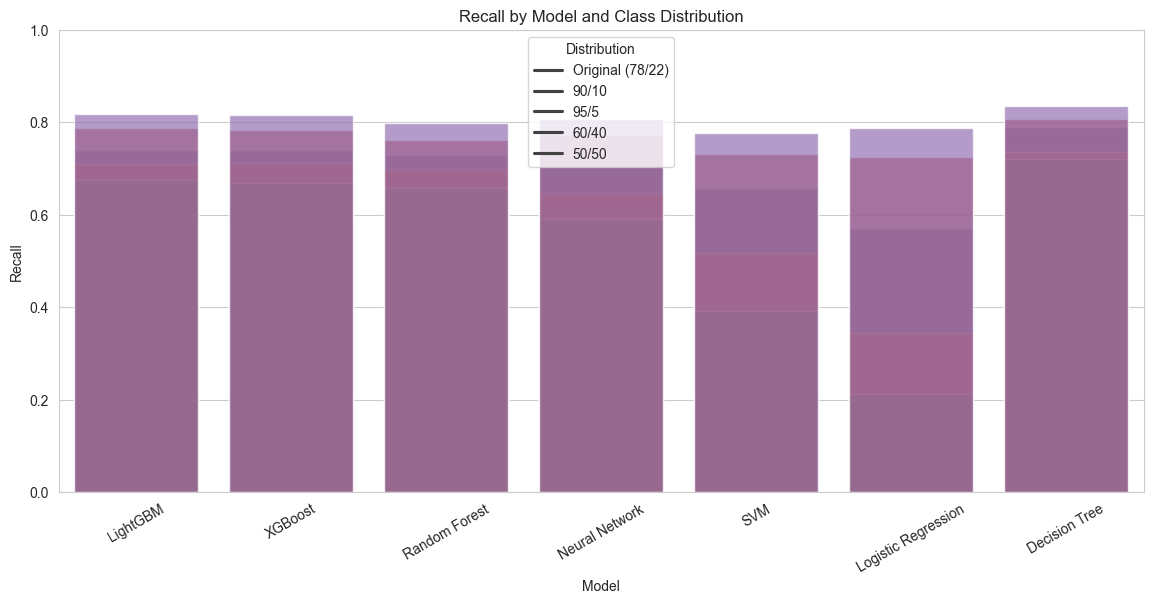

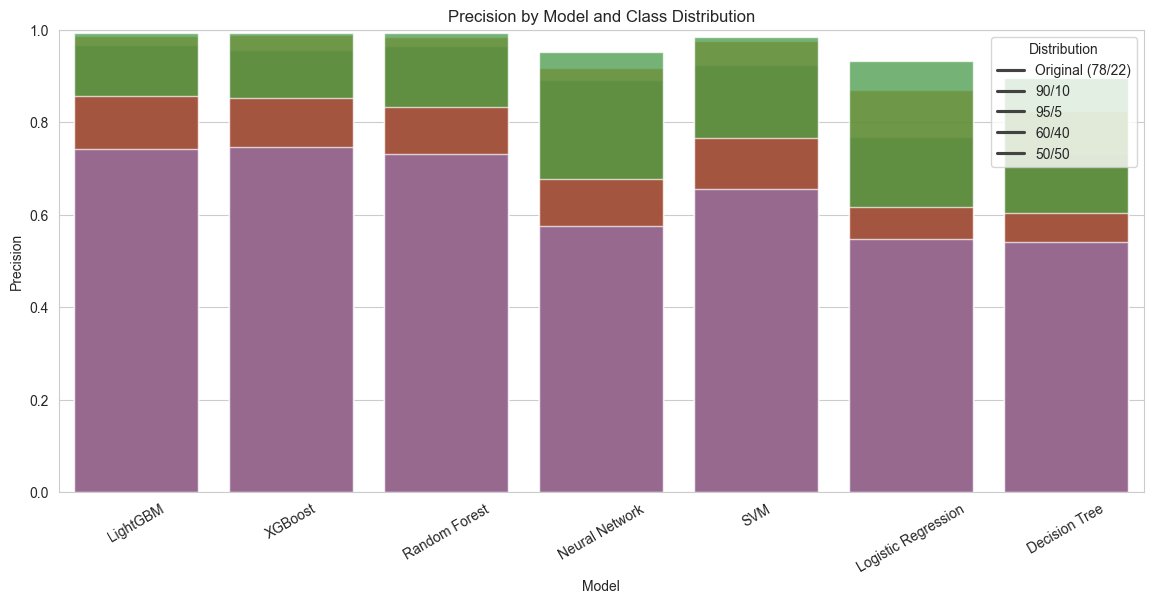

In [39]:
# Barplots: Model Performance under Different Class Distributions
import matplotlib.pyplot as plt
import seaborn as sns

results_dict = {
    "Original (78/22)": results_original,
    "90/10": results_90,
    "95/5": results_95,
    "60/40": results_60,
    "50/50": results_50
}

metrics = ["ROC-AUC", "F1", "Recall", "Precision"]

for metric in metrics:
    plt.figure(figsize=(14, 6))
    for label, df in results_dict.items():
        # Sort models for consistent coloring/order
        plot_df = df.set_index("Model").loc[results_original["Model"]].reset_index()
        sns.barplot(x="Model", y=metric, data=plot_df, label=label, alpha=0.7)
    plt.title(f"{metric} by Model and Class Distribution")
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.xticks(rotation=30)
    plt.legend(results_dict.keys(), title="Distribution")
    plt.ylim(0, 1)
    plt.show()

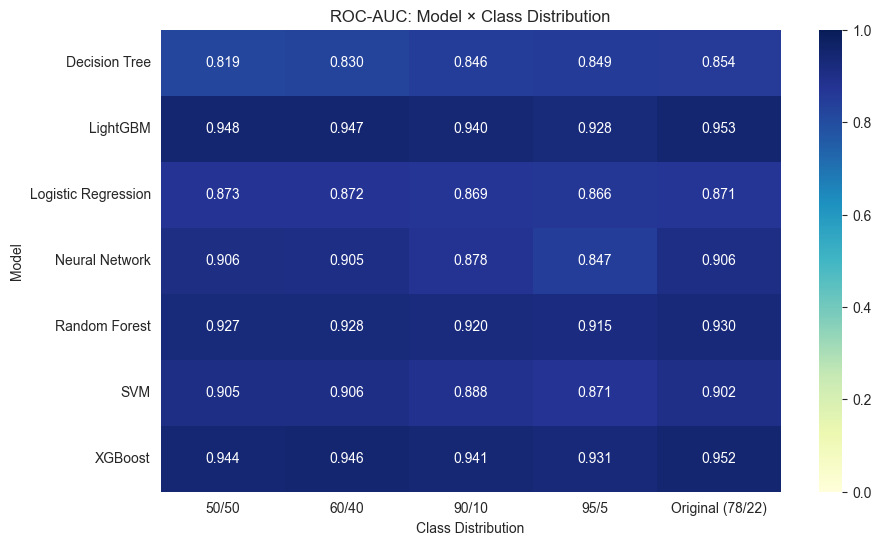

In [40]:
# Heatmap: Model × Distribution Performance

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Combine results for heatmap
heatmap_df = []
for label, df in results_dict.items():
    temp = df.copy()
    temp["Distribution"] = label
    heatmap_df.append(temp)
heatmap_df = pd.concat(heatmap_df, ignore_index=True)

# Pivot for heatmap (ROC-AUC)
pivot_auc = heatmap_df.pivot(index="Model", columns="Distribution", values="ROC-AUC")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_auc, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("ROC-AUC: Model × Class Distribution")
plt.ylabel("Model")
plt.xlabel("Class Distribution")
plt.show()

In [41]:
# ========================================================
# EXPERIMENT 3: EXPLANATION STABILITY ACROSS DISTRIBUTIONS
# ========================================================

In [42]:
# =========================================
# TRAIN MODELS FOR DIFFERENT DISTRIBUTIONS
# =========================================

import copy

model_original = copy.deepcopy(models["LightGBM"])
model_90 = copy.deepcopy(models["LightGBM"])
model_95 = copy.deepcopy(models["LightGBM"])
model_60 = copy.deepcopy(models["LightGBM"])
model_50 = copy.deepcopy(models["LightGBM"])

# Now train separately
model_original.fit(X_train, y_train)
model_90.fit(X_train_90, y_train_90)
model_95.fit(X_train_95, y_train_95)
model_60.fit(X_train_60, y_train_60)
model_50.fit(X_train_50, y_train_50)

[LightGBM] [Info] Number of positive: 4975, number of negative: 17831
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000458 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 913
[LightGBM] [Info] Number of data points in the train set: 22806, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218144 -> initscore=-1.276513
[LightGBM] [Info] Start training from score -1.276513
[LightGBM] [Info] Number of positive: 1981, number of negative: 17831
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000443 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 904
[LightGBM] [Info] Number of data points in the train set: 19812, number of used features: 25
[LightGBM] [Info] [bin

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [43]:
# =========================================
# GET FEATURE NAMES AFTER PREPROCESSING
# =========================================

preprocessor.fit(X_train)

feature_names = preprocessor.get_feature_names_out()

In [44]:
import shap

# Transform test data
X_test_transformed = preprocessor.transform(X_test)

# Create SHAP explainer
explainer = shap.TreeExplainer(model_original.named_steps["classifier"])

shap_values_original = explainer.shap_values(X_test_transformed)

/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [45]:
explainer_90 = shap.TreeExplainer(model_90.named_steps["classifier"])
shap_values_90 = explainer_90.shap_values(X_test_transformed)

explainer_95 = shap.TreeExplainer(model_95.named_steps["classifier"])
shap_values_95 = explainer_95.shap_values(X_test_transformed)

explainer_60 = shap.TreeExplainer(model_60.named_steps["classifier"])
shap_values_60 = explainer_60.shap_values(X_test_transformed)

explainer_50 = shap.TreeExplainer(model_50.named_steps["classifier"])
shap_values_50 = explainer_50.shap_values(X_test_transformed)

In [46]:
import numpy as np

def get_shap_importance(shap_values):
    return np.abs(shap_values).mean(axis=0)

In [47]:
imp_original = get_shap_importance(shap_values_original)
imp_90 = get_shap_importance(shap_values_90)
imp_95 = get_shap_importance(shap_values_95)
imp_60 = get_shap_importance(shap_values_60)
imp_50 = get_shap_importance(shap_values_50)

In [48]:
import pandas as pd

def shap_df(importance, feature_names):
    df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })
    return df.sort_values(by="Importance", ascending=False)

df_orig = shap_df(imp_original, feature_names)
df_90 = shap_df(imp_90, feature_names)
df_95 = shap_df(imp_95, feature_names)
df_60 = shap_df(imp_60, feature_names)
df_50 = shap_df(imp_50, feature_names)

In [49]:
print("Original (78/22) Top Features:")
display(df_orig.head(10))

print("90/10 Top Features:")
display(df_90.head(10))

print("95/5 Top Features:")
display(df_95.head(10))

print("60/40 Top Features:")
display(df_60.head(10))

print("50/50 Top Features:")
display(df_50.head(10))

Original (78/22) Top Features:


,Feature,Importance
5,num__loan_percent_income,0.949963
1,num__person_income,0.842972
9,cat__person_home_ownership_OWN,0.668173
4,num__loan_int_rate,0.556223
16,cat__loan_intent_VENTURE,0.446133
10,cat__person_home_ownership_RENT,0.402485
17,cat__loan_grade_A,0.299368
20,cat__loan_grade_D,0.229784
3,num__loan_amnt,0.169874
13,cat__loan_intent_HOMEIMPROVEMENT,0.160531


90/10 Top Features:


,Feature,Importance
1,num__person_income,0.737338
9,cat__person_home_ownership_OWN,0.648013
5,num__loan_percent_income,0.630632
4,num__loan_int_rate,0.585055
16,cat__loan_intent_VENTURE,0.348371
10,cat__person_home_ownership_RENT,0.340572
17,cat__loan_grade_A,0.309403
20,cat__loan_grade_D,0.257645
3,num__loan_amnt,0.207191
2,num__person_emp_length,0.165798


95/5 Top Features:


,Feature,Importance
1,num__person_income,0.709387
5,num__loan_percent_income,0.582524
9,cat__person_home_ownership_OWN,0.563962
4,num__loan_int_rate,0.495335
10,cat__person_home_ownership_RENT,0.427644
16,cat__loan_intent_VENTURE,0.400081
17,cat__loan_grade_A,0.336828
20,cat__loan_grade_D,0.286809
3,num__loan_amnt,0.224600
2,num__person_emp_length,0.209375


60/40 Top Features:


,Feature,Importance
5,num__loan_percent_income,1.176204
1,num__person_income,0.843903
4,num__loan_int_rate,0.655244
9,cat__person_home_ownership_OWN,0.623238
10,cat__person_home_ownership_RENT,0.464622
16,cat__loan_intent_VENTURE,0.373003
20,cat__loan_grade_D,0.330563
3,num__loan_amnt,0.243861
17,cat__loan_grade_A,0.211546
13,cat__loan_intent_HOMEIMPROVEMENT,0.194919


50/50 Top Features:


,Feature,Importance
5,num__loan_percent_income,1.328305
1,num__person_income,0.863267
4,num__loan_int_rate,0.675821
9,cat__person_home_ownership_OWN,0.594276
10,cat__person_home_ownership_RENT,0.398056
16,cat__loan_intent_VENTURE,0.363598
20,cat__loan_grade_D,0.331974
3,num__loan_amnt,0.215608
17,cat__loan_grade_A,0.201700
13,cat__loan_intent_HOMEIMPROVEMENT,0.184835


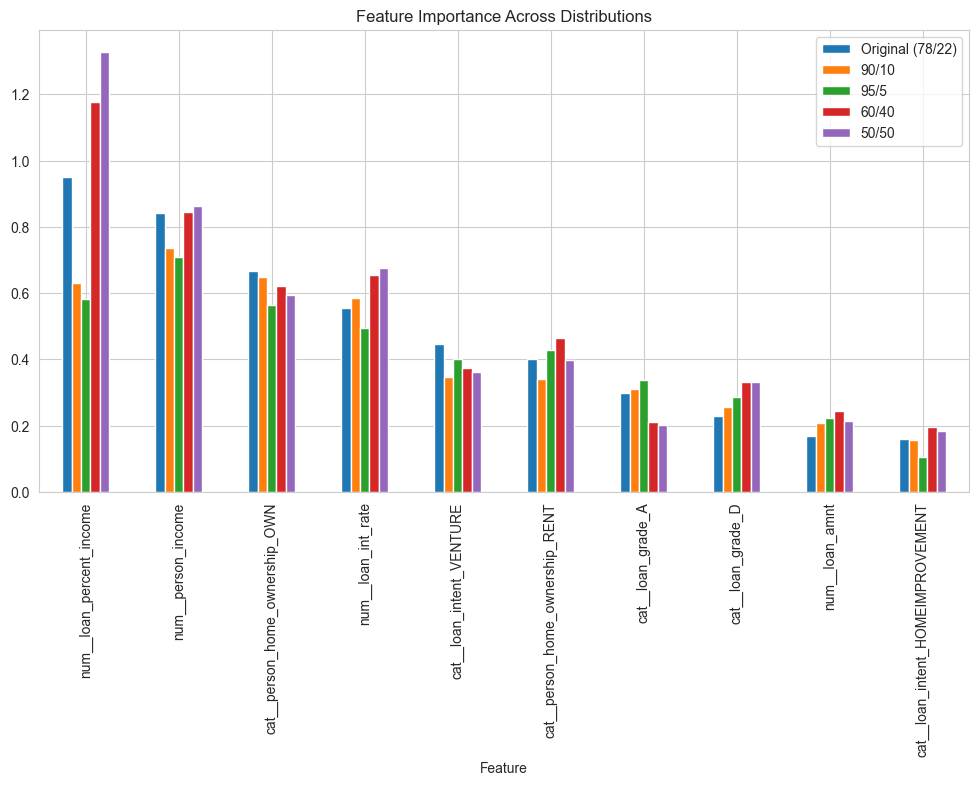

In [50]:
import matplotlib.pyplot as plt

top_features = df_orig.head(10)["Feature"]

comparison = pd.DataFrame({
    "Original (78/22)": df_orig.set_index("Feature").loc[top_features]["Importance"],
    "90/10": df_90.set_index("Feature").loc[top_features]["Importance"],
    "95/5": df_95.set_index("Feature").loc[top_features]["Importance"],
    "60/40": df_60.set_index("Feature").loc[top_features]["Importance"],
    "50/50": df_50.set_index("Feature").loc[top_features]["Importance"]
})

comparison.plot(kind="bar", figsize=(12,6))
plt.title("Feature Importance Across Distributions")
plt.show()

In [51]:
# =========================================
# ADD RANK COLUMN TO ALL DATAFRAMES
# =========================================

df_orig = df_orig.reset_index(drop=True)
df_90 = df_90.reset_index(drop=True)
df_95 = df_95.reset_index(drop=True)
df_60 = df_60.reset_index(drop=True)
df_50 = df_50.reset_index(drop=True)

df_orig["Rank"] = range(1, len(df_orig) + 1)
df_90["Rank"] = range(1, len(df_90) + 1)
df_95["Rank"] = range(1, len(df_95) + 1)
df_60["Rank"] = range(1, len(df_60) + 1)
df_50["Rank"] = range(1, len(df_50) + 1)

In [52]:
# =========================================
# MERGE ALL RANKS INTO ONE DATAFRAME
# =========================================

rank_compare = df_orig[["Feature", "Rank"]].rename(columns={"Rank": "Rank_Orig"})

rank_compare = rank_compare.merge(
    df_90[["Feature", "Rank"]].rename(columns={"Rank": "Rank_90"}),
    on="Feature"
)

rank_compare = rank_compare.merge(
    df_95[["Feature", "Rank"]].rename(columns={"Rank": "Rank_95"}),
    on="Feature"
)

rank_compare = rank_compare.merge(
    df_60[["Feature", "Rank"]].rename(columns={"Rank": "Rank_60"}),
    on="Feature"
)

rank_compare = rank_compare.merge(
    df_50[["Feature", "Rank"]].rename(columns={"Rank": "Rank_50"}),
    on="Feature"
)

rank_compare = rank_compare.sort_values(by="Rank_Orig")

rank_compare

,Feature,Rank_Orig,Rank_90,Rank_95,Rank_60,Rank_50
0,num__loan_percent_income,1,3,2,1,1
1,num__person_income,2,1,1,2,2
2,cat__person_home_ownership_OWN,3,2,3,4,4
3,num__loan_int_rate,4,4,4,3,3
4,cat__loan_intent_VENTURE,5,5,6,6,6
5,cat__person_home_ownership_RENT,6,6,5,5,5
6,cat__loan_grade_A,7,7,7,9,9
7,cat__loan_grade_D,8,8,8,7,7
8,num__loan_amnt,9,9,9,8,8
9,cat__loan_intent_HOMEIMPROVEMENT,10,12,15,10,10


In [53]:
rank_compare["Total_Shift"] = (
    abs(rank_compare["Rank_90"] - rank_compare["Rank_Orig"]) +
    abs(rank_compare["Rank_95"] - rank_compare["Rank_Orig"]) +
    abs(rank_compare["Rank_60"] - rank_compare["Rank_Orig"]) +
    abs(rank_compare["Rank_50"] - rank_compare["Rank_Orig"])
)

rank_compare = rank_compare.sort_values(by="Total_Shift", ascending=False)

In [54]:
rank_compare

,Feature,Rank_Orig,Rank_90,Rank_95,Rank_60,Rank_50,Total_Shift
11,cat__loan_grade_B,12,15,18,17,17,19
15,num__person_age,16,11,12,14,15,12
13,cat__loan_intent_DEBTCONSOLIDATION,14,13,11,12,12,8
9,cat__loan_intent_HOMEIMPROVEMENT,10,12,15,10,10,7
18,num__cb_person_cred_hist_length,19,18,14,19,20,7
17,cat__person_home_ownership_MORTGAGE,18,17,17,18,13,7
16,cat__loan_grade_E,17,20,19,16,18,7
25,cat__cb_person_default_on_file_Y,26,24,24,25,26,5
23,cat__loan_grade_G,24,26,26,24,24,4
6,cat__loan_grade_A,7,7,7,9,9,4


/var/folders/x2/p857nctj7hndgfwnttbcz4jh0000gn/T/ipykernel_13555/2117661196.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


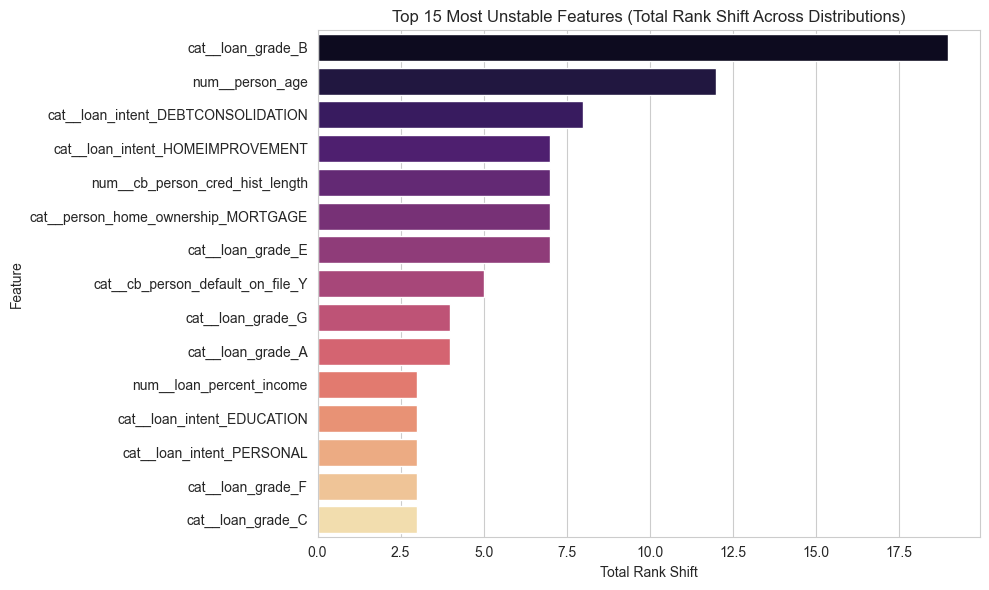

In [55]:
# Total Rank Shift Barplot: Most Unstable Features Across Distributions
import matplotlib.pyplot as plt
import seaborn as sns

# Show top 15 most unstable features
top_shift = rank_compare.head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_shift,
    y="Feature",
    x="Total_Shift",
    palette="magma"
)
plt.title("Top 15 Most Unstable Features (Total Rank Shift Across Distributions)")
plt.xlabel("Total Rank Shift")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [56]:
# =========================================
# EXPERIMENT 4: MODEL EXPLANATION AGREEMENT
# =========================================

In [57]:
import copy
import shap
import numpy as np

def get_model_shap_importance(model, X_train, y_train, X_test, preprocessor):
    model_copy = copy.deepcopy(model)
    model_copy.fit(X_train, y_train)

    X_test_transformed = preprocessor.transform(X_test)

    clf = model_copy.named_steps["classifier"]
    explainer = shap.TreeExplainer(clf)

    shap_values = explainer.shap_values(X_test_transformed)

    # HANDLE ALL CASES
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # class 1

    shap_values = np.array(shap_values)

    # If 3D → (samples, features, classes)
    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]  # take class 1

    # Final importance
    importance = np.abs(shap_values).mean(axis=0)

    print("SHAP shape:", shap_values.shape)

    return importance

In [58]:
imp_lgb = get_model_shap_importance(models["LightGBM"], X_train, y_train, X_test, preprocessor)
imp_xgb = get_model_shap_importance(models["XGBoost"], X_train, y_train, X_test, preprocessor)
imp_rf = get_model_shap_importance(models["Random Forest"], X_train, y_train, X_test, preprocessor)

[LightGBM] [Info] Number of positive: 4975, number of negative: 17831
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000464 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 913
[LightGBM] [Info] Number of data points in the train set: 22806, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218144 -> initscore=-1.276513
[LightGBM] [Info] Start training from score -1.276513


/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP shape: (4888, 26)
SHAP shape: (4888, 26)
SHAP shape: (4888, 26)


In [59]:
def shap_df(importance, feature_names):
    df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })
    return df.sort_values(by="Importance", ascending=False)

df_lgb = shap_df(imp_lgb, feature_names)
df_xgb = shap_df(imp_xgb, feature_names)
df_rf  = shap_df(imp_rf, feature_names)

In [60]:
top_lgb = set(df_lgb.head(15)["Feature"])
top_xgb = set(df_xgb.head(15)["Feature"])
top_rf  = set(df_rf.head(15)["Feature"])

common_features = top_lgb & top_xgb & top_rf

print("Common top features across all models:")
for f in common_features:
    print("-", f)

Common top features across all models:
- num__loan_amnt
- cat__person_home_ownership_OWN
- cat__loan_intent_VENTURE
- cat__loan_intent_MEDICAL
- cat__loan_intent_DEBTCONSOLIDATION
- num__loan_int_rate
- num__person_income
- cat__person_home_ownership_RENT
- num__person_emp_length
- cat__loan_grade_A
- cat__loan_intent_HOMEIMPROVEMENT
- num__loan_percent_income
- cat__loan_grade_D


In [61]:
# ====================
# EXPERIMENT 5: TABNET
# ====================

In [62]:
# =========================================
# SELECT BEST MODEL (LIGHTGBM)
# =========================================

best_model = models["LightGBM"]

In [63]:
# Combine train + validation
X_full_train = pd.concat([X_train, X_val])
y_full_train = pd.concat([y_train, y_val])

print("Full training shape:", X_full_train.shape)

Full training shape: (27693, 11)


In [64]:
# Train final model
best_model.fit(X_full_train, y_full_train)

[LightGBM] [Info] Number of positive: 6041, number of negative: 21652
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000517 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 915
[LightGBM] [Info] Number of data points in the train set: 27693, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.218142 -> initscore=-1.276528
[LightGBM] [Info] Start training from score -1.276528


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [65]:
import joblib
import os

# Create folder if not exists
os.makedirs("model", exist_ok=True)

# Save quantile bounds for outlier handling
joblib.dump(quantile_bounds, "model/quantile_bounds.pkl")

# Save pipeline (preprocessing + model)
joblib.dump(best_model, "model/credit_risk_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [66]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

joblib.dump(feature_names, "model/feature_names.pkl")

print("✅ Feature names saved!")

✅ Feature names saved!


In [67]:
import joblib

model = joblib.load("model/credit_risk_model.pkl")

print("✅ Model loaded")

✅ Model loaded


In [68]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/archith25/Developer/My_Workspace/Explainable_Credit_Risk_Prediction/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [69]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("\n=== FINAL MODEL TEST PERFORMANCE ===")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))


=== FINAL MODEL TEST PERFORMANCE ===
Accuracy : 0.939443535188216
Precision: 0.9638989169675091
Recall   : 0.7507029053420806
F1 Score : 0.8440463645943098
ROC-AUC  : 0.9523150193266776


In [70]:
metadata = {
    "model": "LightGBM",
    "features": list(feature_names),
    "target": "loan_status"
}

joblib.dump(metadata, "model/model_metadata.pkl")

['model/model_metadata.pkl']